#DBSCAN

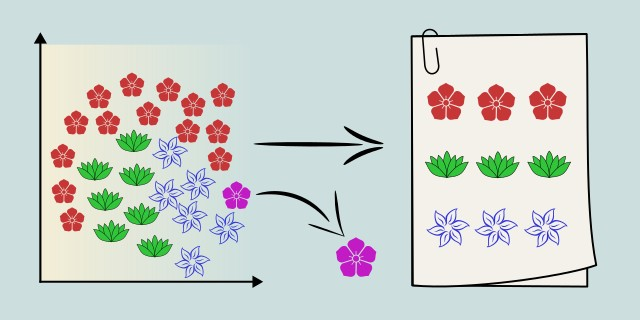

DBSCAN stands for Density-Based Spatial Clustering of Applications with Noise

It is an unsupervised machine learning clustering algorithm that groups data points based on density instead of distance from a centroid (like K-Means).

#Two Hyperparameters

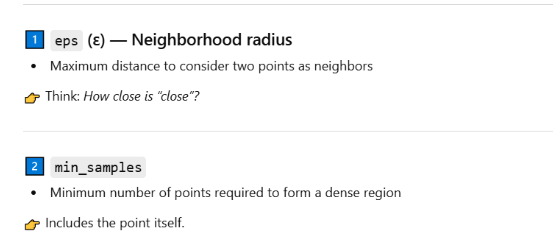

DBSCAN starts from one point and checks how many neighboring points are within a certain radius

If there are enough nearby points, it creates a cluster and keeps expanding it

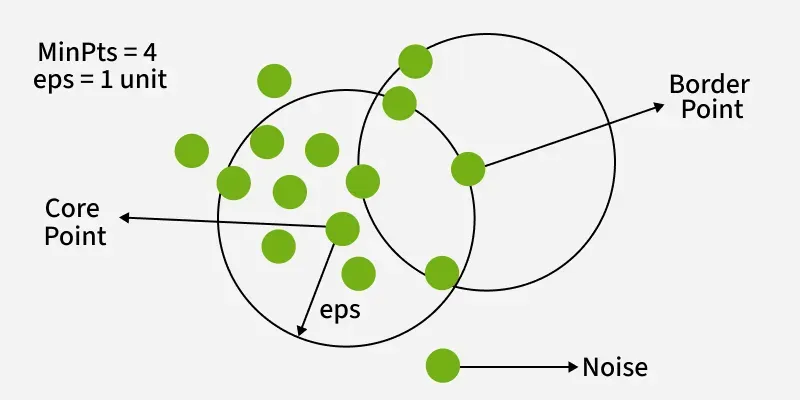

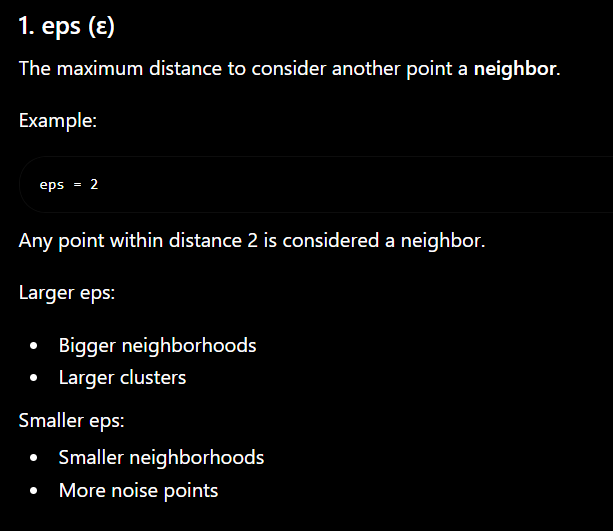

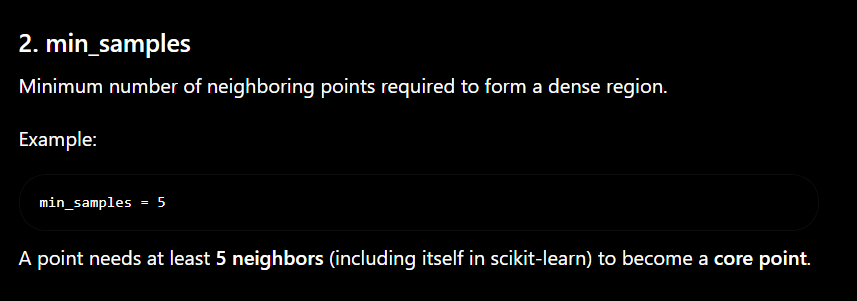

#Types of Points in DBSCAN

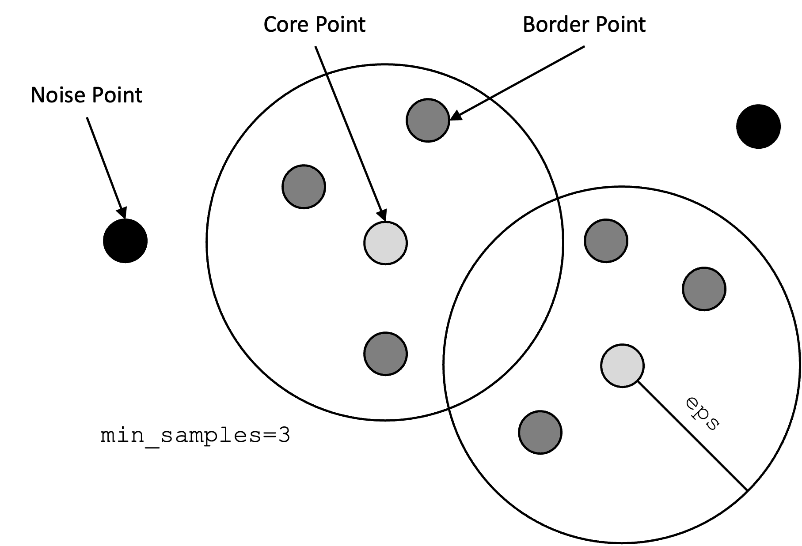

There are 3 types.

1. Core Point

A point that has at least min_samples points within eps.


2. Border Point

Has fewer than min_samples neighbors, but is close to a core point.



3. Noise Point

Not close enough to any cluster.



#Example

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [55]:
df=pd.read_csv("/content/iris.csv")

In [56]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


Step 1

drop Target Column

make the data "x"

In [57]:
x=df.drop("target",axis=1)

In [58]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [60]:
dbscan = DBSCAN(
    eps= 1,
    min_samples=5,
    metric='euclidean'
)

labels = dbscan.fit_predict(X_scaled)

In [61]:
labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [62]:
unique_labels = set(labels)
unique_labels

{np.int64(-1), np.int64(0), np.int64(1)}

In [63]:
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_clusters

2

In [64]:
n_noise = list(labels).count(-1)
n_noise

3

In [65]:
print("Clusters found:", unique_labels)
print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Clusters found: {np.int64(0), np.int64(1), np.int64(-1)}
Number of clusters: 2
Number of noise points: 3


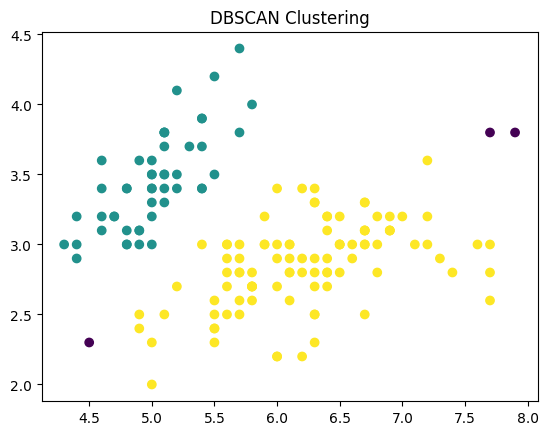

In [66]:
import matplotlib.pyplot as plt

# Plot the clusters
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=labels)
plt.title("DBSCAN Clustering")
plt.show()

In [68]:
if n_clusters > 1:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)
else:
    print("Silhouette Score not defined (only one cluster)")


Silhouette Score: 0.5382884306788227


#EX2

In [40]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import pandas as pd



In [41]:
df=pd.read_csv("/content/dbscan_data.csv")
df

,Feature_1,Feature_2,True_Label
0,-7.109308,-7.305032,2
1,-7.309834,-7.072387,2
2,-2.097925,8.403864,0
3,4.531038,2.522558,1
4,-7.898689,-7.384153,2
...,...,...,...
295,-3.084694,9.202135,0
296,4.225381,1.693079,1
297,-3.312939,9.106603,0
298,-6.870418,-6.041891,2


In [42]:
x=df.drop("True_Label",axis=1)

In [43]:
# Create DBSCAN model
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

In [45]:
# Train the model and predict cluster labels
labels = dbscan.fit_predict(x)

In [46]:
labels

array([ 0,  0,  1,  2,  0,  2,  1,  2,  1,  1,  1,  2,  1,  1,  0,  1,  0,
        2,  1,  1,  1,  1,  2,  0,  1,  0,  0, -1,  2,  1,  1,  1,  0,  1,
        0,  1,  0,  2,  0,  2,  2,  1,  0,  2,  1,  1,  0,  2,  0,  2,  2,
        0,  0,  1,  0, -1,  0,  1,  2,  1,  0,  2,  2, -1,  0,  2,  2,  0,
        0,  1,  2,  0,  0,  1,  1,  0,  0,  2,  1,  2,  1,  1,  0,  1,  2,
        0,  0,  1,  2,  1,  0,  1,  0,  1,  1,  0,  0,  1,  0,  0,  2,  1,
        2,  1,  1,  1,  1,  1,  2,  0,  2,  1,  1,  1,  1,  2,  0,  2,  0,
        2,  2,  2,  1,  0,  0,  0,  0,  1,  0,  0,  1,  1,  1,  1,  1,  2,
        2,  0,  1,  0,  1,  1,  0,  1,  2,  2,  2,  1,  2,  1,  1,  0,  2,
        0,  1,  2,  2,  0,  0,  1, -1,  0,  0,  0,  1,  0,  2,  1,  1,  1,
        1,  1,  2,  1,  2,  2,  2,  1,  2,  2,  0,  1,  0,  2,  2,  0,  2,
        1, -1,  2,  0,  0,  2,  0,  2,  2,  2,  2,  1,  0,  1,  1,  2,  2,
        1,  2,  0,  0,  2,  1,  1,  0,  2,  2,  0,  0,  0,  0,  1,  0,  0,
        2,  0,  0,  1,  2

In [47]:
unique_labels = set(labels)


n_clusters = len(unique_labels) - (1 if -1 in labels else 0)



n_noise = list(labels).count(-1)



print("Clusters found:", unique_labels)
print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)


Clusters found: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
Number of clusters: 3
Number of noise points: 5


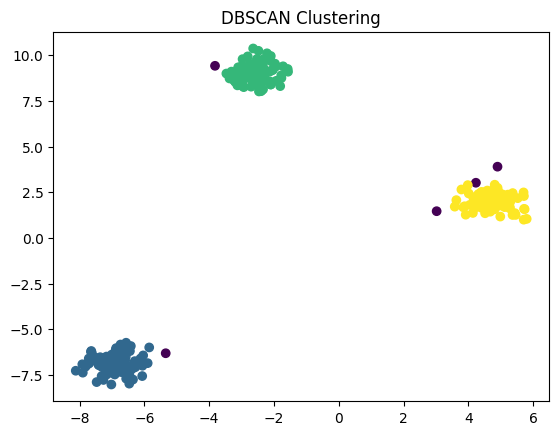

In [51]:
import matplotlib.pyplot as plt

# Plot the clusters
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=labels)
plt.title("DBSCAN Clustering")
plt.show()

In [53]:
if n_clusters > 1:
    score = silhouette_score(x, labels)
    print("Silhouette Score:", score)
else:
    print("Silhouette Score not defined (only one cluster)")


Silhouette Score: 0.8718102993767503
